## Data Aggrigation

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df_train = pd.read_csv('drugsComTrain_raw.csv')
df_test = pd.read_csv('drugsComTest_raw.csv')

In [171]:
data = pd.concat([df_train,df_test])

In [115]:
data.sample(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
6689,205129,Acetaminophen / aspirin / caffeine,Migraine,"""I was diagnosed with a brain tumor and this w...",10,9-Oct-13,18
19894,184345,Hydroxyzine,Anxiety,"""It worked for a while then it stopped working...",1,12-Mar-15,30
153874,221941,Fluconazole,Vaginal Yeast Infection,"""I took the 150mg and within 24 hrs I felt way...",10,4-Apr-17,16
88151,67396,Lacosamide,Seizures,"""I have been on Vimpat for four years and have...",10,21-Apr-17,26
83925,70605,Flomax,Urinary Tract Stones,"""Helped me pass my stone within 3 hours of tak...",10,27-Aug-09,66


In [116]:
df = data.copy()

In [117]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount
52819,63262,Difluprednate,Postoperative Ocular Inflammation,"""Durezol was prescribed by my doctor following...",10,28-Sep-13,26
14155,63290,Epiduo,Acne,"""I used to use Adapalene only which was very s...",10,22-Aug-17,1
28608,13103,Xolair,"Asthma, Maintenance","""6 months 2 injections every 2 week. Sorry gu...",1,21-Nov-17,0
47919,31753,Miconazole,Vaginal Yeast Infection,"""Ok everyone, I have frequent yeast infections...",9,6-Dec-15,31
78384,56146,Estradiol,Atrophic Vaginitis,"""I didn&#039;t realize how much this was a gre...",10,2-Aug-09,31
88297,9329,Lo Loestrin Fe,Birth Control,"""This is my first ever pill I used. The first ...",5,28-Jan-17,1
53131,139483,Armodafinil,Hypersomnia,"""Significantly improved my quality of life wit...",9,21-Jan-11,8
159679,172505,Clonazepam,Anxiety,"""I started this Drug in 2004 because because o...",10,1-Apr-16,25
34695,142839,Levonorgestrel,Birth Control,"""I&#039;ve had this for a month- perfect. No p...",10,2-Jul-17,1
17217,183492,Cymbalta,ibromyalgia,"""I have had pain for 10 years. Since taking Cy...",10,24-Jan-11,22


From initial observation, I can say that condition and review column consists of invalid char so it need to be cleaned

## Basic anaysis

In [118]:
df.shape

(215063, 7)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215063 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 13.1+ MB


Data column is in string format. It need to be converted into date format

In [120]:
df.describe()

,uniqueID,rating,usefulCount
count,215063.000000,215063.000000,215063.000000
mean,116039.364814,6.990008,28.001004
std,67007.913366,3.275554,36.346069
min,0.000000,1.000000,0.000000
25%,58115.500000,5.000000,6.000000
50%,115867.000000,8.000000,16.000000
75%,173963.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [121]:
df.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

In [122]:
df.duplicated().sum()

np.int64(0)

There are 1194 rows are null values in condition column

In [123]:
df.corr(numeric_only=True)

,uniqueID,rating,usefulCount
uniqueID,1.000000,0.016336,0.017567
rating,0.016336,1.000000,0.234860
usefulCount,0.017567,0.234860,1.000000


## Univariate analysis

In [124]:
from wordcloud import WordCloud, STOPWORDS

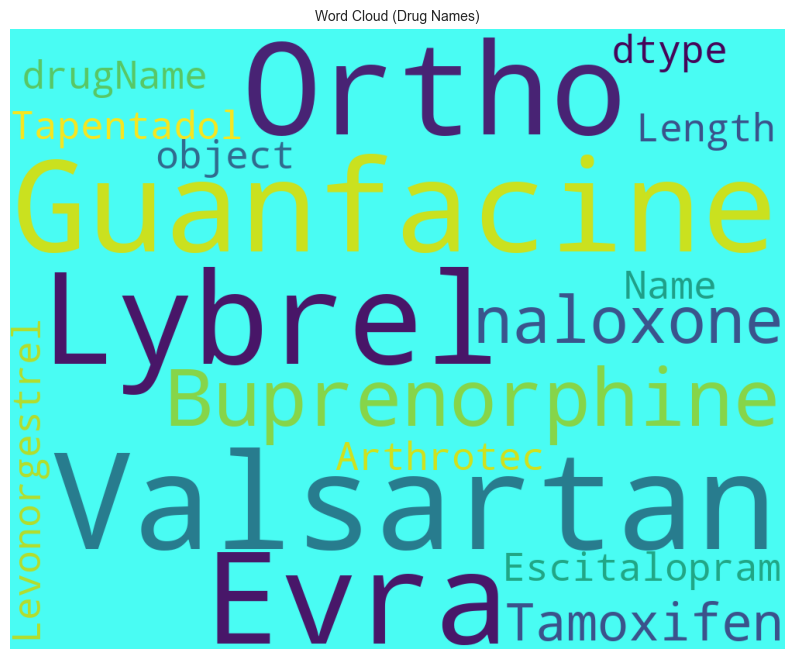

In [125]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['drugName']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (Drug Names)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

The above cloud includes the metadata as well like dtype, Length etc. Because the str(pd.Series) includes meta data as well

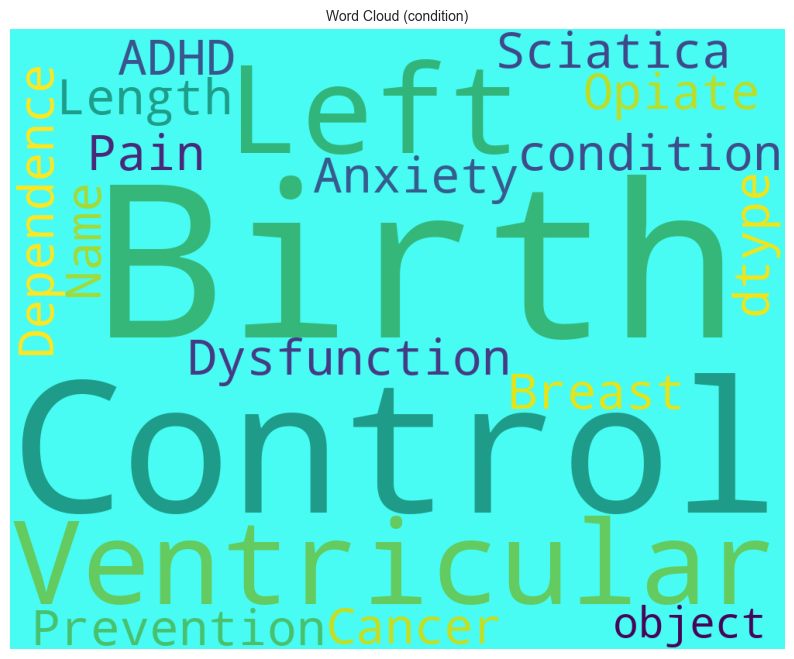

In [126]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['condition']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (condition)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

Most of the times, we can see the birth control, ADHD, Ventricular etc

<Axes: ylabel='count'>

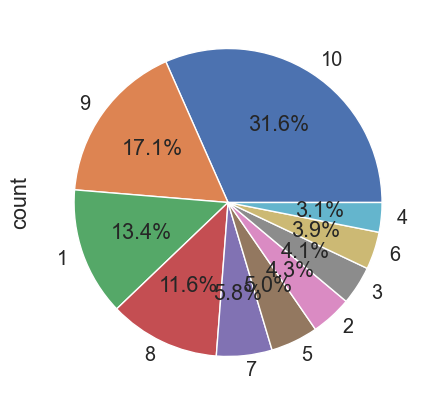

In [127]:
df['rating'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: xlabel='rating', ylabel='Density'>

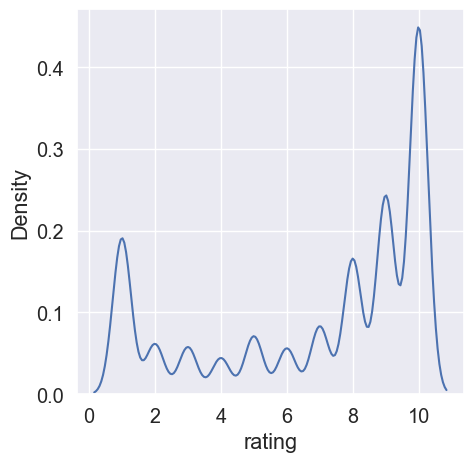

In [128]:
sns.kdeplot(df['rating'])

Most of the ratings are higher ratings ie 10, 9, 8. Some drugs about 13% also got worst rating 1

In [129]:
print((df['rating'] > 5).sum())
print((df['rating'] <= 5).sum())

150768
64295


Data is imbalance by a huge difference. May be the data includes so much of positive drugs. Hence the model may not perform well on negative drugs so well

## Bivariante analysis

C:\Users\91939\AppData\Local\Temp\ipykernel_21792\3663489246.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


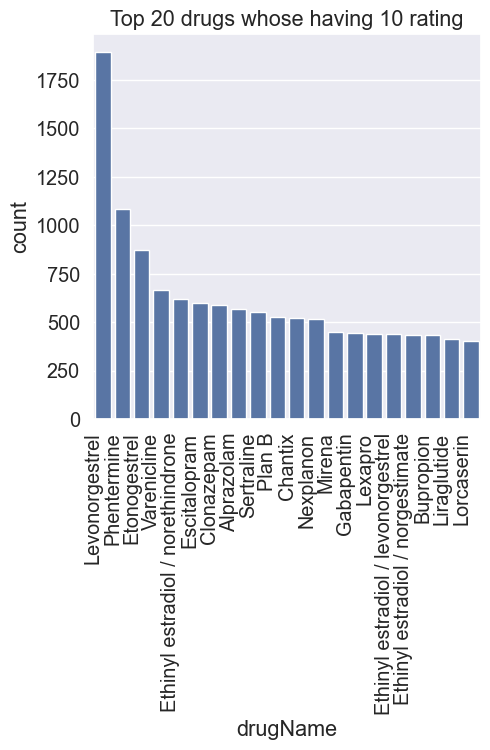

In [130]:
top_drugs_10 = df[df['rating'] == 10]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_10)
bar.set_title('Top 20 drugs whose having 10 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [17, 5]

C:\Users\91939\AppData\Local\Temp\ipykernel_21792\1902578690.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


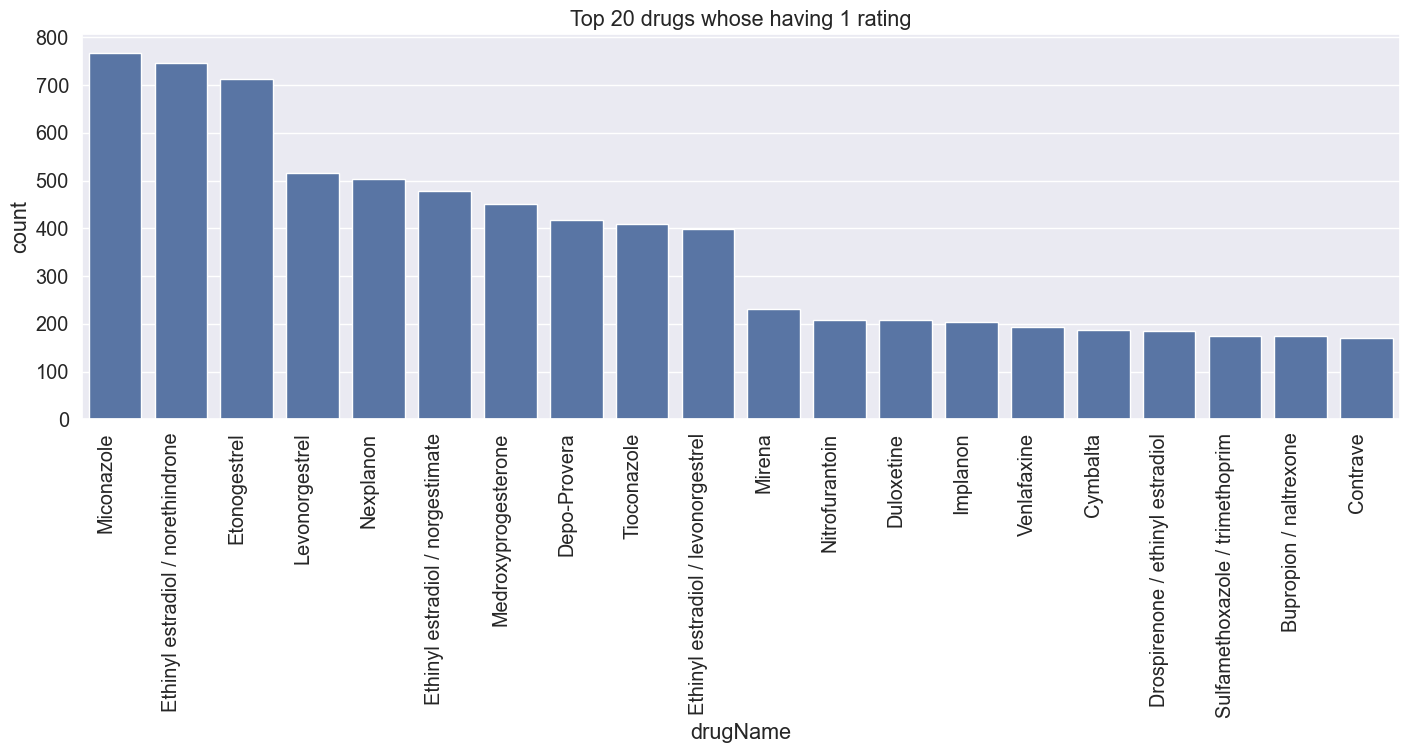

In [131]:
top_drugs_1 = df[df['rating'] == 1]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_1)
bar.set_title('Top 20 drugs whose having 1 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [8, 8]

C:\Users\91939\AppData\Local\Temp\ipykernel_21792\4106974381.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


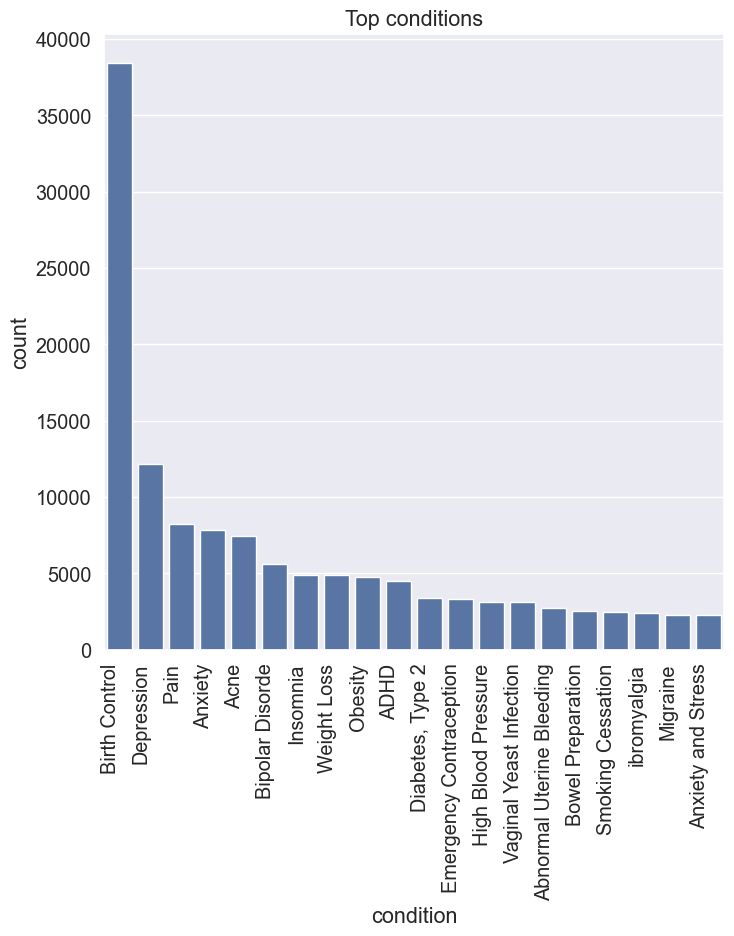

In [132]:
top_conditions = df['condition'].value_counts().head(20)
bar=sns.barplot(top_conditions)
bar.set_title('Top conditions')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [5, 5]

### visualizing as per date

In [133]:
df['date'] = pd.to_datetime(df['date'])

C:\Users\91939\AppData\Local\Temp\ipykernel_21792\3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [134]:
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day

In [135]:
df.head(2)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,2012,5,20
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,2010,4,27


Text(0.5, 1.0, 'Mean rating in a year')

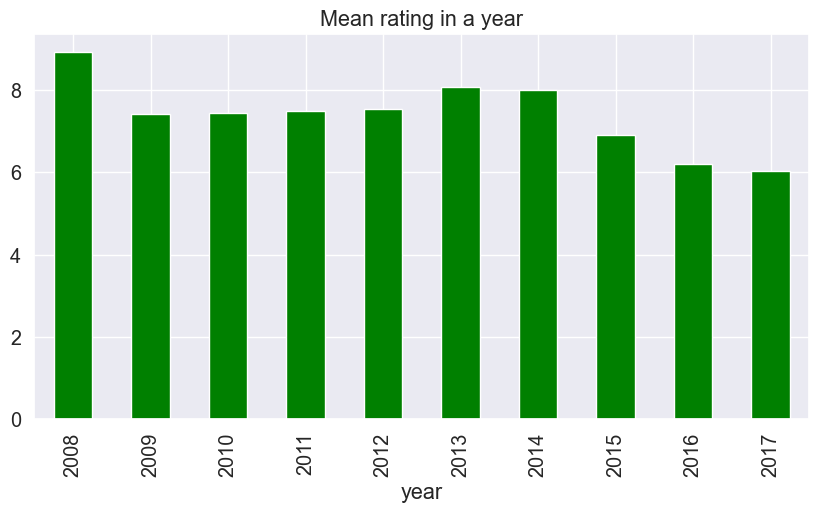

In [136]:
rating=df.groupby('year')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a year')

Text(0.5, 1.0, 'Mean rating in a month')

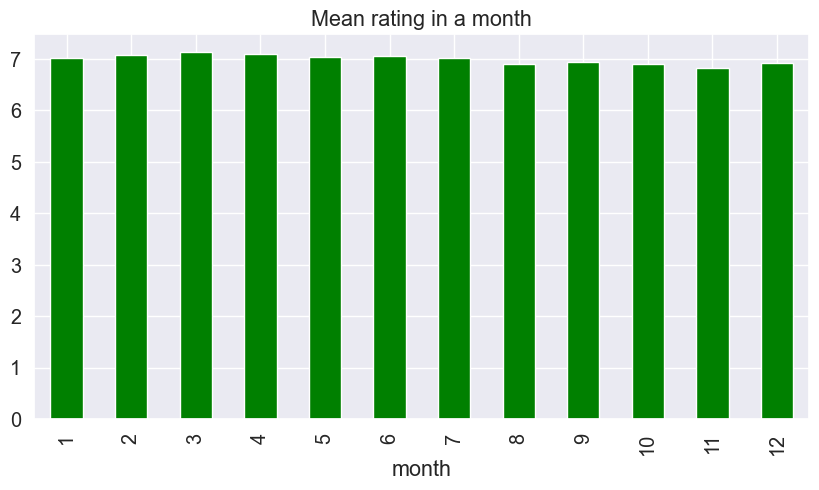

In [137]:
rating=df.groupby('month')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a month')

Text(0.5, 1.0, 'Mean rating in a day')

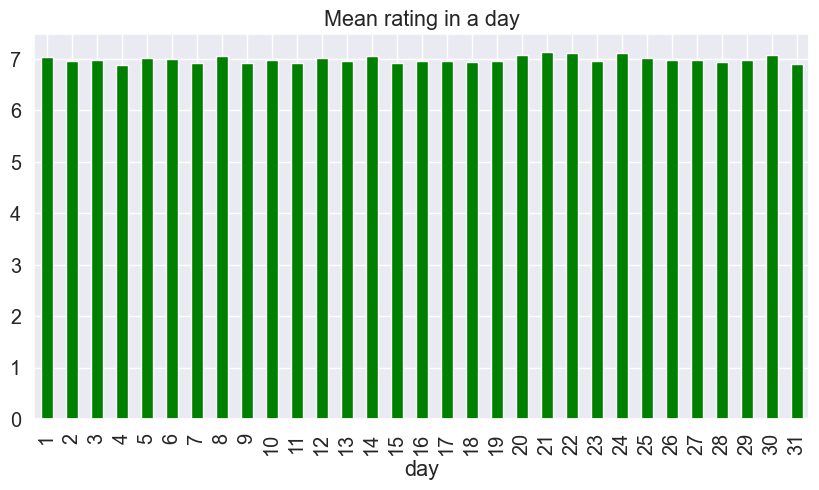

In [138]:
rating=df.groupby('day')['rating'].mean()
rating.plot(kind='bar',figsize=(10,5),color='green')
plt.title('Mean rating in a day')

As we seen the data is distributed equally across the year, month and day. So no need of date column

### Usefull count visualization

In [139]:
df["usefulCount"].describe()

count    215063.000000
mean         28.001004
std          36.346069
min           0.000000
25%           6.000000
50%          16.000000
75%          36.000000
max        1291.000000
Name: usefulCount, dtype: float64

As we see the stdev is so high and the data distribution is so large. So normalizing it will helpfull

In [140]:
df['usefulCount'].nunique()

397

C:\Users\91939\AppData\Local\Temp\ipykernel_21792\2665249276.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["usefulCount"],color="green")


Text(0.5, 1.0, 'Distribution of usefulCount')

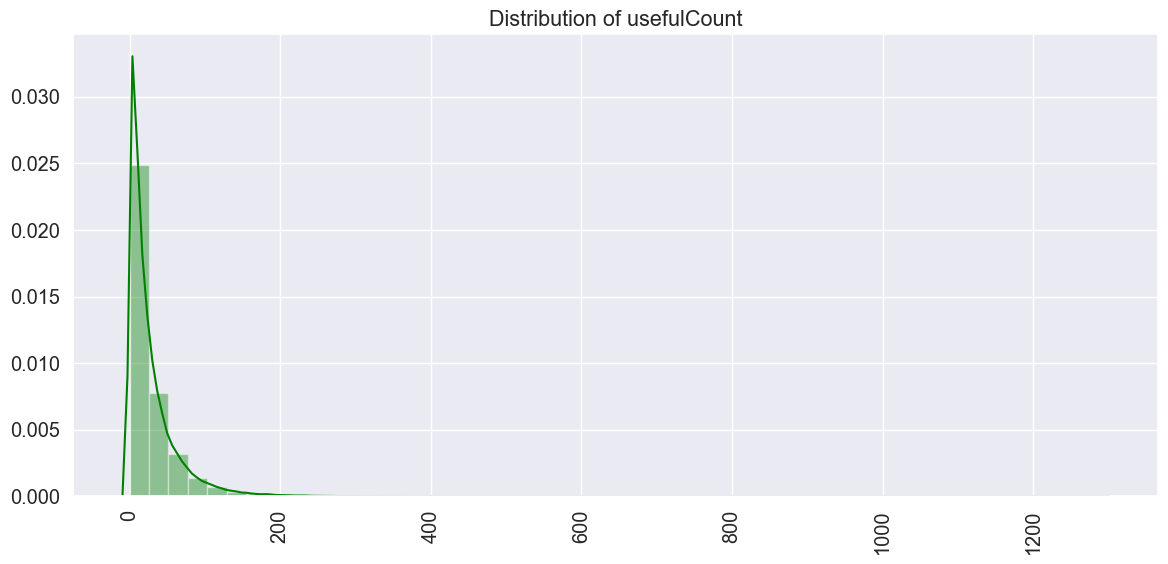

In [141]:
plt.figure(figsize=(14,6))
sns.distplot(df["usefulCount"],color="green")
plt.xticks(rotation='vertical')
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.title("Distribution of usefulCount")

## Text preprocessing

#### Droping null values

In [142]:
df=df.dropna(how="any", axis=0)

In [143]:
import re
def process(text):
    cleaned_text = re.sub(re.compile('<.*?>'), '', text) #removes html tags
    cleaned_text = cleaned_text.lower() #lowers the data
    cleaned_text = cleaned_text.replace(r'[^\w\d\s]',' ') #removes the special characters
    cleaned_text = cleaned_text.replace(r'[^\x00-\x7F]+',' ') # remove all non aschi values
    cleaned_text = cleaned_text.strip() #removes trailing and leading spaces
    cleaned_text = cleaned_text.replace(r'\s+',' ') # replace multiple spaces with single one
    cleaned_text = cleaned_text.replace(r'\.{2,}', ' ') # replace multiple . with single
    cleaned_text = cleaned_text.replace("&#039;", "") #remove repeating pattern
    
    return cleaned_text

### condition series preprocessing

In [144]:
df['condition'] = df['condition'].apply(process)

In [145]:
df['review'] = df['review'].apply(process)

In [146]:
df.sample(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
87582,175193,Linaclotide,constipation,"""day three of 290 linzess and nothing! x-rays...",1,2013-04-11,47,2013,4,11
25853,21197,Multivitamin with iron,anemia,"""helpful!""",10,2013-05-01,9,2013,5,1
151418,62890,Fortesta,"hypogonadism, male","""worked well and fast, easy to use, no stank, ...",9,2013-10-01,22,2013,10,1
81420,225845,Bupropion,bipolar disorde,"""i have taken wellbutrin sr for about 8 months...",9,2010-08-09,35,2010,8,9
54070,32987,Seasonique,birth control,"""i have been so happy on this medication. i ac...",9,2012-04-18,20,2012,4,18
61302,151845,Chantix,smoking cessation,"""smoked for 20 years, quit for 4 years, smoked...",10,2013-04-05,26,2013,4,5
61886,111070,Verapamil,cluster headaches,"""im a 56 year old male and started having ch a...",4,2015-12-10,12,2015,12,10
98582,58732,Hydrochlorothiazide / telmisartan,high blood pressure,"""very satisfied, ive been using micardis plus ...",10,2017-04-27,0,2017,4,27
36741,96345,Sertraline,anxiety and stress,"""i started using zoloft for anxiety and minor ...",9,2009-09-09,57,2009,9,9
3751,191123,Campral,alcohol dependence,"""it works.""",9,2008-12-17,29,2008,12,17


After doing the preprocessing, in some reviews we find \r, \n and emojis and @amp for and . So remove them also

In [147]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+",
    flags=re.UNICODE,
)

In [148]:
df['review'] = (df['review'].str.replace(r'[\n\r]+', ' ', regex=True).str.replace(emoji_pattern, '', regex=True))

In [149]:
df['review'] = df['review'].str.replace('&amp;', 'and', regex=True)
df['review'] = df['review'].str.replace('&quot;', 'and', regex=True)

In [150]:
df.sample(20)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,month,day
36032,178687,Victoza,weight loss,"""ive been on the drug for about 10 months. lo...",8,2016-09-01,65,2016,9,1
65368,124342,Skyla,birth control,"""today, i had the skyla inserted in me. it too...",6,2016-01-09,0,2016,1,9
79997,105872,Atomoxetine,adhd,"""so ive been using strattera 40-50-60mg since ...",5,2017-07-18,13,2017,7,18
40489,177833,Duloxetine,back pain,"""ive been taking 60mg for 2 years for back pai...",8,2013-06-06,3,2013,6,6
12583,85370,Ethinyl estradiol / norgestimate,birth control,"""i was on this pill for a little more than one...",7,2015-05-30,11,2015,5,30
18031,148866,Mirena,birth control,"""just had it inserted today and it was pretty ...",6,2015-11-24,2,2015,11,24
26517,126394,Naphazoline,nasal congestion,"""i wish they would bring this back to the mark...",10,2014-04-14,23,2014,4,14
115970,163043,Decadron,allergic rhinitis,"""although i have to go to the doctor and get a...",10,2010-02-09,15,2010,2,9
12164,210414,Linzess,irritable bowel syndrome,"""i am 37 year old female who has been sufferin...",8,2014-02-15,76,2014,2,15
51677,44487,Ethinyl estradiol / norgestimate,birth control,"""i didnt like this birth control at all. i hav...",5,2009-11-01,1,2009,11,1


Now the review and conditions looks good

## Feature Engineering

In [151]:
df.drop(columns=['date','year','month','day','uniqueID'],inplace=True)

In [152]:
df.sample()

,drugName,condition,review,rating,usefulCount
8664,Savella,ibromyalgia,"""the pain is down, but i am having trouble sle...",7,13


In [153]:
df['sentiment'] = df["rating"].apply(lambda x: 1 if x > 5 else 0)

In [154]:
df.sample(5)

,drugName,condition,review,rating,usefulCount,sentiment
66219,Voltaren Gel,pain,"""was using this for achilles micro tears from ...",6,35,1
10692,Tramadol,pain,"""made me very ill after one tablet. vomiting f...",2,8,0
121968,Depo-Provera,birth control,"""i have used many types of birth controls from...",6,2,1
3369,Quetiapine,bipolar disorde,"""when i was first put on this medication in th...",10,53,1
53738,Diclofenac,pain,"""this drug is an excellent anti-inflammatory. ...",4,9,0


#### Feature representation

In [155]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [156]:
from nltk.corpus import stopwords

sw_list = stopwords.words('english')
df['review'] = df['review'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

In [157]:
df.sample(5)

,drugName,condition,review,rating,usefulCount,sentiment
24465,Buspirone,anxiety,"""i tried buspar addition 200mg zoloft. meant e...",3,27,0
117966,Intuniv,adhd,"""im add, h included. 11 year old daughter also...",1,93,0
136688,Fluticasone,rhinitis,"""great product using 10 years. smoker using pr...",9,19,1
12953,Desogestrel / ethinyl estradiol,birth control,"""id say good/decent pill overall, pills decide...",9,1,1
92969,Drospirenone / ethinyl estradiol,birth control,"""i used yaz years problems gianvi made moody, ...",1,5,0


In [158]:
df.loc[df['condition'] == '0 users found this comment helpful.'].shape

(128, 6)

In [159]:
df['condition'] = df['condition'].str.replace('0 users found this comment helpful.', 'Not Specified', regex=True)

In [160]:
df.loc[df['condition'] == 'Not Specified'].head(3)

,drugName,condition,review,rating,usefulCount,sentiment
516,Nortrel 1 / 35,Not Specified,"""they switched necon nortrel saying andsameand...",2,0,0
553,Loestrin 24 Fe,Not Specified,"""i loestrin 24 fe 6 months never problems emot...",7,0,1
571,Ortho Tri-Cyclen Lo,Not Specified,"""i love birth control spotting periods. little...",9,0,1


In [161]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [162]:
from nltk.stem import SnowballStemmer
from textblob import TextBlob

In [163]:
Snow_ball = SnowballStemmer("english")
df['review'] = df['review'].apply(lambda x: " ".join(Snow_ball.stem(word) for word in x.split()))

In [166]:
df.sample(3)

,drugName,condition,review,rating,usefulCount,sentiment
75135,Blisovi 24 Fe,birth control,"""ive experienc exact other comment here. fine ...",1,3,0
50781,Aleve,back pain,"""not good thc effect me. one want solut allow ...",9,20,1
76453,Trileptal,bipolar disorde,"""after reaction lamict topamax- trilept didnt ...",9,46,1


In [167]:
# to determine the polarity of the review
def sentiment(review):
    pol = []
    for i in review:
        analysis = TextBlob(i)
        pol.append(analysis.sentiment.polarity)
    return pol

In [170]:
df['review_sentiment'] = sentiment(df['review'])

In [173]:
df.sample(10)

,drugName,condition,review,rating,usefulCount,sentiment,review_sentiment
29069,Cyclobenzaprine,muscle spasm,"""i take flexeril muscl spasm back. would relia...",5,43,0,0.000000
36300,Avelox,bacterial infection,"""mi second time take avelox pneumonia. benefit...",8,9,1,-0.120833
8069,Mucinex,ibromyalgia,"""i diagnos 20 put muscl relax pain killer noth...",10,145,1,0.000000
33159,Cymbalta,major depressive disorde,"""i use cymbalta 60mg night. sleep better, eat ...",9,40,1,0.325298
47961,Xulane,birth control,"""the patch caus itchi goe away. notic breast f...",7,4,1,0.487500
37561,Cevimeline,sjogren's syndrome,"""while take evoxac sever bodi odor, genit smel...",1,9,0,0.097727
67302,Yaz,birth control,"""i actual love yaz. wasnt moodi lost 20 lbs it...",9,8,1,0.052083
23555,Losartan,high blood pressure,"""took losartan 50 mg three days. im experienc ...",1,47,0,0.000000
59652,Mirtazapine,anxiety,"""at first remeron amazing. felt much better sh...",6,74,1,0.170000
132789,Varenicline,smoking cessation,"""2nd time use chantix. work first work time! n...",10,19,1,0.195312


In [174]:
df.corr(numeric_only=True)

,rating,usefulCount,sentiment,review_sentiment
rating,1.000000,0.235121,0.916406,0.287993
usefulCount,0.235121,1.000000,0.212763,0.073422
sentiment,0.916406,0.212763,1.000000,0.261538
review_sentiment,0.287993,0.073422,0.261538,1.000000


In [191]:
import nltk
nltk.download('punkt_tab')
from nltk import sent_tokenize
import gensim
from gensim.utils import simple_preprocess

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [199]:
df['tokens'] = df['review'].apply(simple_preprocess)

In [200]:
from gensim.models import Word2Vec

sentences = df['tokens'].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [202]:
w2v_model.train(sentences,total_examples=w2v_model.corpus_count,epochs=w2v_model.epochs)

(40958989, 46130600)